# Data Processing of Customer Support Dataset
The dataset has the following specs:

* Use Case: Intent Detection
* Vertical: Customer Service
* 27 intents assigned to 10 categories
* 26872 question/answer pairs, around 1000 per intent
* 30 entity/slot types
* 12 different types of language generation tags

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Download dataset from HuggingFacer
print("Downloading dataset")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")

#Convert to pandas to easy manipualtion
df = dataset.to_pandas()

print("Dataset load successfullly! Here is a preview of the columns")
display(df.head(3))


Dataset load successfullly! Here is a preview of the columns


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [13]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,do you ship to {{Delivery City}}?,ACCOUNT,check_invoice,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB


In [12]:
df.isna().sum()

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

In [5]:
df.columns

Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='str')

In [4]:
top_intends = df['intent'].value_counts().head(10)
top_intends

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
Name: count, dtype: int64

In [24]:
print("""
    
    flags: tags (explained below in the Language Generation Tags section)
      Tags for Lexical variation
      
    instruction: a user request from the Customer Service domain
    category: the high-level semantic category for the intent
    intent: the intent corresponding to the user instruction
    response: an example expected response from the virtual assistant

""")
print(df.iloc[0])



    flags: tags (explained below in the Language Generation Tags section)
      Tags for Lexical variation

    instruction: a user request from the Customer Service domain
    category: the high-level semantic category for the intent
    intent: the intent corresponding to the user instruction
    response: an example expected response from the virtual assistant


flags                                                          B
instruction     question about cancelling order {{Order Number}}
category                                                   ORDER
intent                                              cancel_order
response       I've understood you have a question regarding ...
Name: 0, dtype: str


In [34]:
df.iloc[0].str.len()

flags            1
instruction     48
category         5
intent          12
response       212
Name: 0, dtype: int64

In [35]:
import matplotlib.pyplot as plt

df['world_count'] = df['response'].str.len()

The average message length is: 634 characters



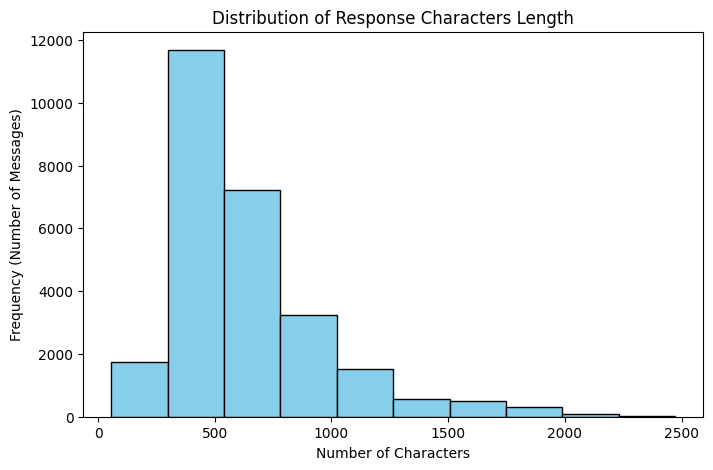

In [51]:
mean_length = df["world_count"].mean()
print(f"The average message length is: {int(mean_length)} characters\n")

df["world_count"].plot(
    kind='hist',
    bins=10,
    edgecolor='black',
    color='skyblue',
    figsize=(8,5)
)

plt.title("Distribution of Response Characters Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency (Number of Messages)")
plt.show()

In [ ]:
#Applying Statistical Filtering to remove outliers


import numpy as np

#Calculate 95% oercentile trheshold
percentile_threshhold = df["world_count"].quantile(0.95)
print(f"95% of responses are shorter than: {percentile_threshhold} characters")

95% of responses are shorter than: 1295.0 characters


In [55]:
#Sanit Check: look at a few of the outliers before deletinh them
outliers = df[df["world_count"] > percentile_threshhold]
print("\nSample of outlies being removed: ")
print(len(outliers))
print(outliers["response"].head(3).values)


Sample of outlies being removed: 
1343
<ArrowStringArray>
['I can sense that you're seeking assistance with canceling your purchase with the purchase number {{Order Number}}. I apologize for any inconvenience caused, and I'm here to guide you through the process.\n\nTo cancel your purchase, please follow these steps:\n\n1. Log into your account: Visit our {{Online Company Portal Info}} and sign in using your credentials.\n2. Locate your order: Once logged in, navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section to find the purchase with the order number {{Order Number}}.\n3. Initiate the cancellation: Upon finding your purchase, look for the option labeled '{{Online Order Interaction}}' and click on it to initiate the cancellation process.\n4. Confirm the cancellation: Our system might ask for confirmation or feedback regarding the cancellation. Kindly provide the necessary information to complete the process.\n5. Seek additional support: If you enc

In [ ]:
#Saving outliers in a new csv before removing Reason They may not be useful for training but can be udeful for RAG
outliers.to_csv("LONG_RESPONSES_OUTLIERS.csv", index=False)

In [58]:
df_clean = df[df["world_count"] <= percentile_threshhold].copy()
print(f"Length before drop outliers: {len(df)}, after drop outliers {len(df_clean)} ")

Length before drop outliers: 26872, after drop outliers 25529 


In [68]:
df["category"].value_counts()

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

TheCategories: 634 characters



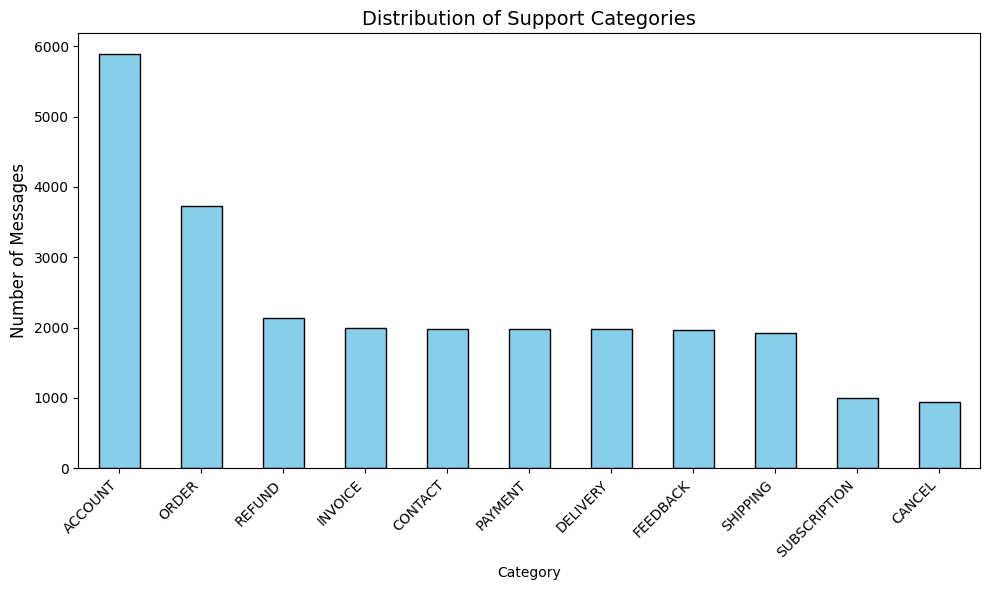

In [71]:
print(f"TheCategories: {int(mean_length)} characters\n")

df_clean["category"].value_counts().plot(
    kind='bar',
    color="skyblue",
    edgecolor="black",
    figsize=(10,6)
)

plt.title('Distribution of Support Categories', fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Messages", fontsize=12)

# 4. Rotate x-axis labels so they don't overlap if the names are long
plt.xticks(rotation=45, ha='right')

# 5. Adjust layout so nothing gets cut off, and show/save the plot
plt.tight_layout()

plt.show()

The intent: 634 characters



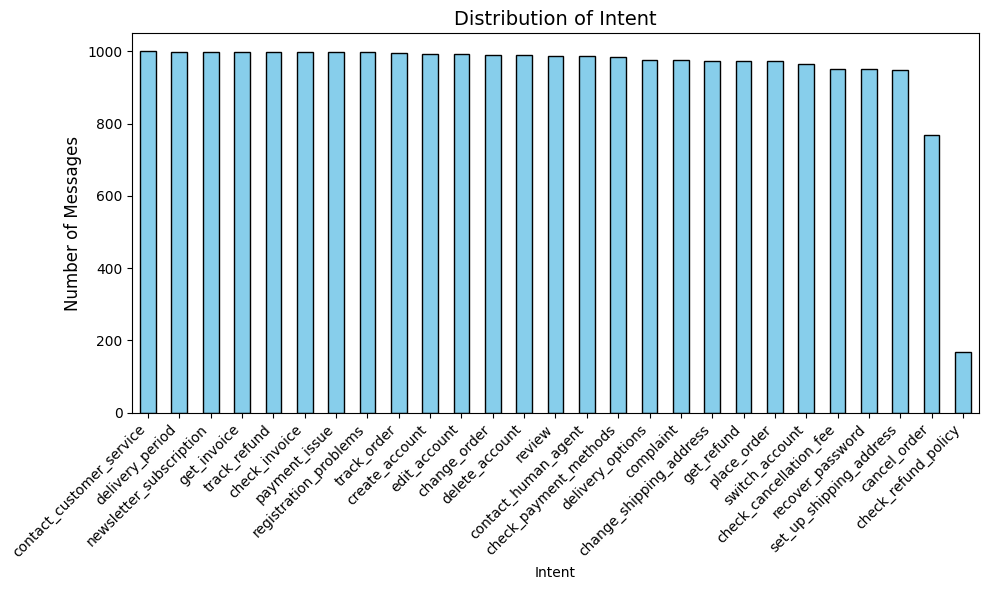

In [76]:
print(f"The intent: {int(mean_length)} characters\n")

df_clean["intent"].value_counts().plot(
    kind='bar',
    color="skyblue",
    edgecolor="black",
    figsize=(10,6)
)

plt.title('Distribution of Intent', fontsize=14)
plt.xlabel("Intent")
plt.ylabel("Number of Messages", fontsize=12)

# 4. Rotate x-axis labels so they don't overlap if the names are long
plt.xticks(rotation=45, ha='right')

# 5. Adjust layout so nothing gets cut off, and show/save the plot
plt.tight_layout()

plt.show()

In [ ]:
#If we only see the category charts it seems our data is heavily unbalanced but when we check the intent distribution we see that our dataset is presampled to be perfectly balanced at the granular level.
#Almost every single intent has exact 1000 messages.

#The only reason the ACCOUNT category looked massive is because it is a "bucket" holding many more intents (create, delete, edit, switch, plus likely 
#others like recover_password and registration_problems.
#  CANCELLATION_FEE looked tiny because it only holds one intent.

In [ ]:
#Well fuck it seems the dataset is already in good shape

#Appl